# 3D Structure Function / CROCO Data

This example will guide you through each step necessary to compute scalar-based structure functions from a 2D CROCO data (space, time).

$\textbf{General procedure}:$


1 -  Load a croco dataset, the dataset can be accessed https://doi.org/10.1175/JPO-D-18-0029.1

2 -  Format dataset to match pyturbo_sf inputs

3 -  Calculate second-order 3D longitudinal structure function as a function of separation distances (space and time)

4 -  Plot the 2D SF with errors and number of bootstraps for different $\delta t$

5 -  Isotropize 3D SF in 2D (r, time)

6 -  Plot Isotropic Longitudinal SF 

7 -  Calculate and plot Time Uncertainty

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load the CROCO Dataset

In [2]:
import xarray as xr
import numpy as np
import pyproj
import gc
import dask

# Set up dask for parallel processing
dask.config.set({"array.chunk-size": "100MB"})

path_data = '/home/aayouche/warrior/data'

# Open datasets with chunking enabled
dsh = xr.open_dataset(path_data + '/surface.nc', 
                     chunks={'time': 50, 'eta_rho': 200, 'xi_rho': 200, 's_rho': 1})
dsg = xr.open_dataset(path_data + '/GOM_150_grd.nc')

# Extract coordinates
lon = dsg.lon_rho
lat = dsg.lat_rho

# Calculate center and UTM zone
lon_center = float(lon.min())
utm_zone = int(1 + (lon_center + 180.0) / 6.0)

# Create the projection
proj = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', datum='WGS84')

# Convert to UTM coordinates
x, y = proj(lon.values, lat.values)
del lon, lat
gc.collect()

# Calculate X and Y
X_2d = 0.25*(x[1:,1:] + x[1:,:-1] + x[:-1,:-1] + x[:-1,1:])
Y_2d = 0.25*(y[1:,1:] + y[1:,:-1] + y[:-1,:-1] + y[:-1,1:])
del x, y
gc.collect()

# Get time values
time_values = dsh.ocean_time.values

# Process u data with dask
u_surface = dsh.u.isel(s_rho=0)
u = 0.5 * (u_surface[:,1:,:] + u_surface[:,:-1,:]).rename({'eta_rho':'y','xi_u':'x'})

# Process v data similarly
v_surface = dsh.v.isel(s_rho=0)
v = 0.5 * (v_surface[:,:,1:] + v_surface[:,:,:-1]).rename({'eta_v':'y','xi_rho':'x'})

# Create the y and x dimensions
y_dim = X_2d.shape[0]
x_dim = X_2d.shape[1]

# Create a time DataArray with proper structure
time = xr.DataArray(
    time_values,
    dims=['time'],
    coords={'time': time_values}
)

# Create X and Y DataArrays with 2D structure
X = xr.DataArray(
    X_2d,
    dims=['y', 'x'],
    coords={
        'y': np.arange(y_dim),
        'x': np.arange(x_dim)
    }
)

Y = xr.DataArray(
    Y_2d,
    dims=['y', 'x'],
    coords={
        'y': np.arange(y_dim),
        'x': np.arange(x_dim)
    }
)

# Broadcast X and Y to include time dimension
# This creates a view with dimensions (time, y, x)
X = X.expand_dims(dim={'time': time_values})
Y = Y.expand_dims(dim={'time': time_values})

# Broadcast time to create a 3D version if needed
# This creates a 3D array with the same value repeated across y and x
time_3d = time.expand_dims(dim={'y': np.arange(y_dim), 'x': np.arange(x_dim)})
time_3d = time_3d.transpose('time', 'y', 'x')
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("time_3d shape:", time_3d.shape)

# Now X, Y, and time_3d all have dimensions (time, y, x)

/tmp/ipykernel_7234/526129619.py:13: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  dsh = xr.open_dataset(path_data + '/surface.nc',
/tmp/ipykernel_7234/526129619.py:13: UserWarning: The specified chunks separate the stored chunks along dimension "eta_rho" starting at index 200. This could degrade performance. Instead, consider rechunking after loading.
  dsh = xr.open_dataset(path_data + '/surface.nc',
/tmp/ipykernel_7234/526129619.py:13: UserWarning: The specified chunks separate the stored chunks along dimension "xi_rho" starting at index 200. This could degrade performance. Instead, consider rechunking after loading.
  dsh = xr.open_dataset(path_data + '/surface.nc',


X shape: (763, 1537, 1025)
Y shape: (763, 1537, 1025)
time_3d shape: (763, 1537, 1025)


# Make a Quick Plot

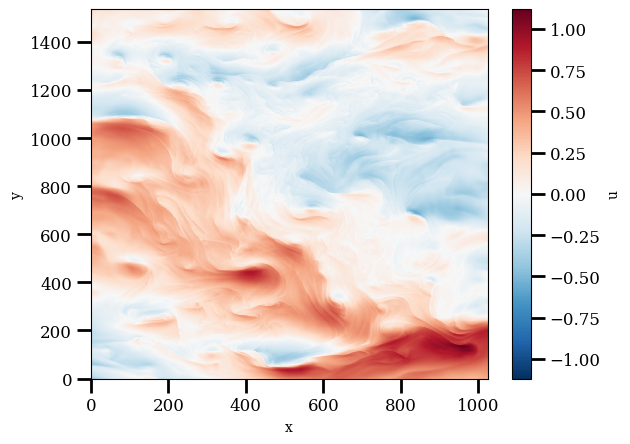

In [3]:
u.isel(time=10).plot()

# Format Dataset

In [4]:
ds = xr.Dataset(
    data_vars={
        'u': u,
        'v': v,
    },
    coords={
        'x': X,
        'y': Y,
        'time': time_3d,
    }
)

In [5]:
ds

<xarray.Dataset> Size: 38GB
Dimensions:  (time: 763, y: 1537, x: 1025)
Coordinates:
    time     (time, y, x) float64 10GB 3.383e+07 3.383e+07 ... 3.658e+07
    y        (time, y, x) float64 10GB 3.039e+06 3.039e+06 ... 3.267e+06
    x        (time, y, x) float64 10GB 3.542e+05 3.544e+05 ... 5.088e+05
Data variables:
    u        (time, y, x) float32 5GB dask.array<chunksize=(50, 199, 513), meta=np.ndarray>
    v        (time, y, x) float32 5GB dask.array<chunksize=(50, 769, 199), meta=np.ndarray>

In [6]:
gc.collect()

132

# Calculate 3D longitudinal SF $\delta_{LL} u(\delta t, \delta_y, \delta_x), \epsilon=1.0$

In [7]:
%%time

bins = {
    'time': np.logspace(np.log10(3600.), np.log10(2743200.0), 12), 
    'x': np.logspace(np.log10(150.), np.log10(155.0e3), 12),
    'y': np.logspace(np.log10(150.), np.log10(155.0e3), 12)
}
sf_result = psf.bin_sf_3d(
    ds=ds,
    variables_names=["u","v"],
    order=2,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':8,'x':8,'time':4},
    initial_nbootstrap=40,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0,
    n_jobs=-1,
    backend='threading'
)

Found time dimension in ['time', 'y', 'x'], allowing flexible dimension names
Dimension 'time' is detected as a time dimension
Using bootsize: {'y': 8, 'x': 8, 'time': 4}
Bootstrappable dimensions: ['time', 'y', 'x']
All three dimensions ['time', 'y', 'x'] are bootstrappable. Available spacings: [1, 2, 4, 8, 16, 32, 64, 128]

STARTING BIN_SF_3D WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 2


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 5 bootstraps
Processing spacing 2 with 5 bootstraps
Processing spacing 4 with 5 bootstraps
Processing spacing 8 with 5 bootstraps
Processing spacing 16 with 5 bootstraps
Processing spacing 32 with 5 bootstraps
Processing spacing 64 with 5 bootstraps
Processing spacing 128 with 5 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 10240
Bins with points: 388/1331
Marked 1055 bins as converged (low_density)
Marked 276 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached m

In [8]:
gc.collect()

0

In [9]:
sf_result

<xarray.Dataset> Size: 50kB
Dimensions:       (time: 11, y: 11, x: 11, edge: 2)
Coordinates:
  * x             (x) float64 88B 205.6 386.5 726.3 ... 6.016e+04 1.131e+05
  * y             (y) float64 88B 205.6 386.5 726.3 ... 6.016e+04 1.131e+05
  * time          (time) float64 88B 4.867e+03 8.898e+03 ... 1.11e+06 2.029e+06
Dimensions without coordinates: edge
Data variables:
    sf            (time, y, x) float64 11kB 0.0009437 0.0009385 ... nan nan
    sf_std        (time, y, x) float64 11kB 0.0005827 0.0004857 ... nan nan
    nbootstraps   (time, y, x) int64 11kB 40 40 40 40 40 40 ... 40 40 40 40 40
    density       (time, y, x) float32 5kB 1.0 0.3192 0.2831 ... 0.0 0.0 0.0
    point_counts  (time, y, x) int64 11kB 75 45 75 50 25 35 35 ... 0 0 0 0 0 0 0
    converged     (time, y, x) bool 1kB True True True True ... True True True
    x_bins        (x, edge) float64 176B 150.0 281.9 ... 8.247e+04 1.55e+05
    y_bins        (y, edge) float64 176B 150.0 281.9 ... 8.247e+04 1.55e+05
    time_bins     (time, edge) float64 176B 3.6e+03 6.581e+03 ... 2.743e+06
Attributes: (12/15)
    bin_type_x:                 logarithmic
    bin_type_y:                 logarithmic
    bin_type_z:                 logarithmic
    convergence_eps:            1.0
    max_nbootstrap:             420
    initial_nbootstrap:         40
    ...                         ...
    variables:                  u,v
    bootstrappable_dimensions:  time,y,x
    time_dimensions:            time
    backend:                    threading
    weighting:                  volume_element
    bootstrap_se_method:        unweighted_std

# Plot for $\delta_t = 8/f$

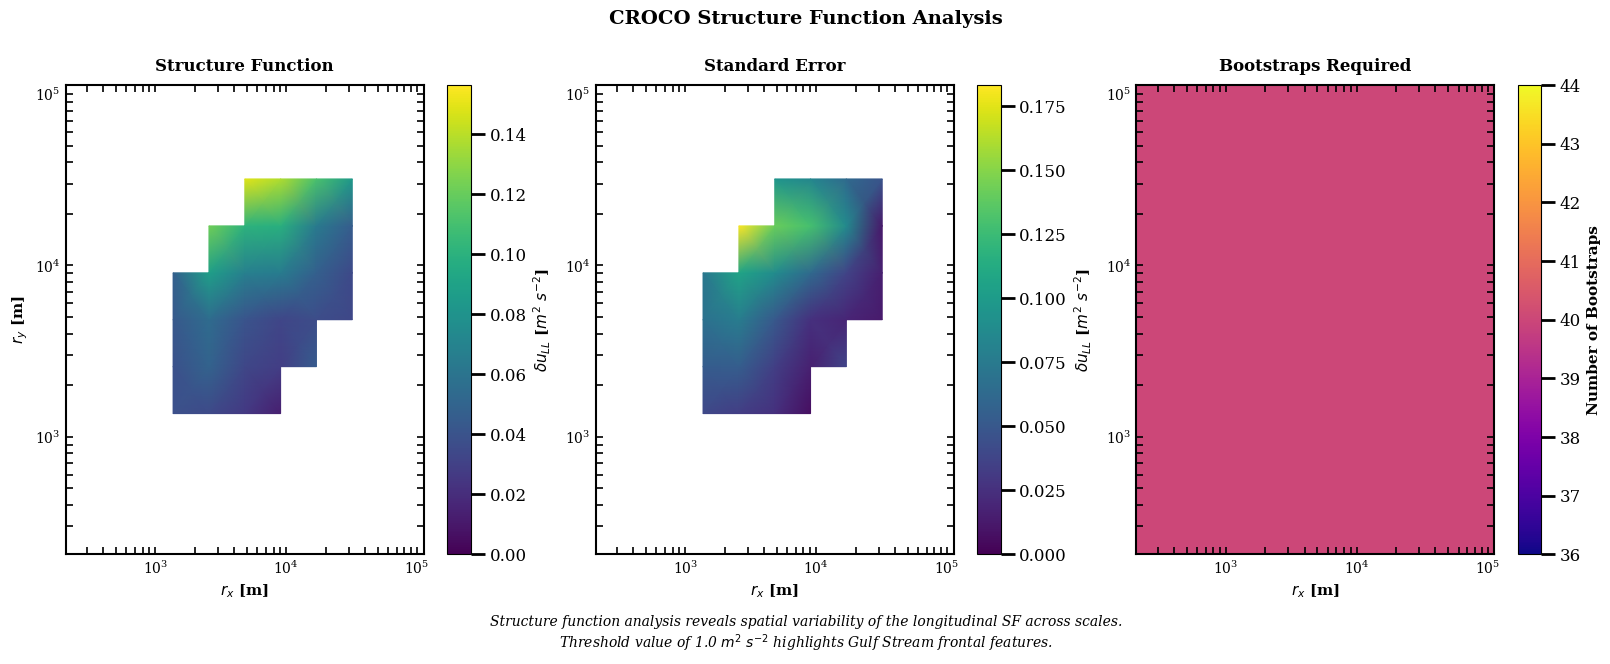

In [12]:
f  = 1.0e-4
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Common settings for all plots
plot_titles = ['Structure Function', 'Standard Error', 'Bootstraps Required']
cmaps = ['viridis', 'viridis', 'plasma']
labels = [r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', 'Number of Bootstraps']

# Data to plot
data_to_plot = [sf_result.sf.sel(time=8/f,method='nearest'), sf_result.sf_std.sel(time=8/f,method='nearest'), sf_result.nbootstraps.sel(time=1/f,method='nearest')]

for i, (ax, data, title, cmap, label) in enumerate(zip(axes, data_to_plot, plot_titles, cmaps, labels)):
    # Create the plot with specific shading for the first plot
    if i == 0:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    else:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    
    # Add colorbar with proper formatting
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=11, fontweight='bold')
    
    # Set axis labels and title
    ax.set_xlabel(r'$r_x$ [m]', fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$r_y$ [m]', fontsize=11, fontweight='bold')
    
    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add title
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Customize spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Customize tick parameters
    ax.tick_params(which='both', direction='in', width=1.2, length=5, 
                  labelsize=10, top=True, right=True)
    

    
    # Add scientific notation for axes
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Add main title for the entire figure
fig.suptitle('CROCO Structure Function Analysis', fontsize=14, fontweight='bold', y=1.08)

# Add annotation explaining the analysis
fig.text(0.5, -0.08, 
         'Structure function analysis reveals spatial variability of the longitudinal SF across scales.\n'
         'Threshold value of 1.0 $m^{2}~s^{-2}$ highlights Gulf Stream frontal features.',
         ha='center', fontsize=10, fontstyle='italic')

plt.show()

# Plot 2D SFs,$\delta_t = 1/f$

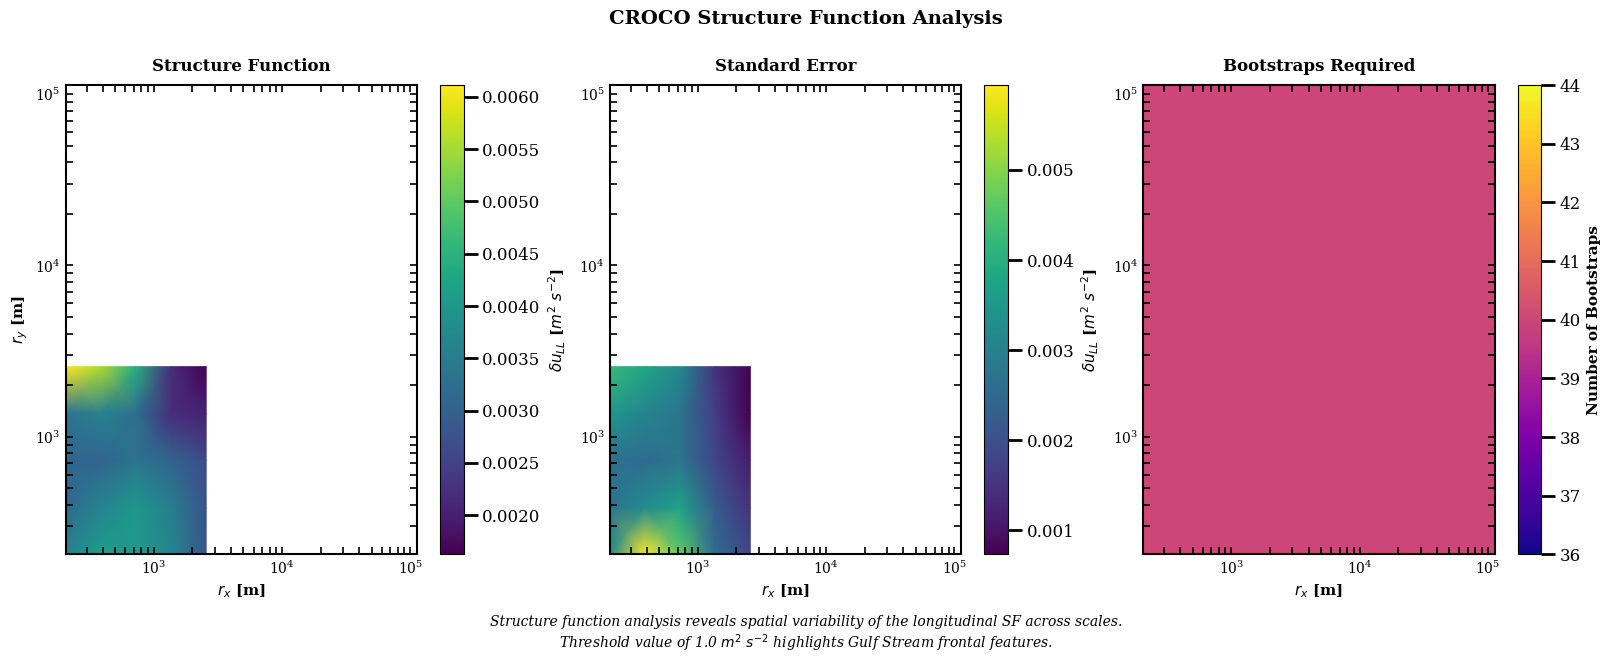

In [13]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Common settings for all plots
plot_titles = ['Structure Function', 'Standard Error', 'Bootstraps Required']
cmaps = ['viridis', 'viridis', 'plasma']
labels = [r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', 'Number of Bootstraps']

# Data to plot
data_to_plot = [sf_result.sf.sel(time=1/f,method='nearest'), sf_result.sf_std.sel(time=1/f,method='nearest'), sf_result.nbootstraps.sel(time=1/f,method='nearest')]

for i, (ax, data, title, cmap, label) in enumerate(zip(axes, data_to_plot, plot_titles, cmaps, labels)):
    # Create the plot with specific shading for the first plot
    if i == 0:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    else:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    
    # Add colorbar with proper formatting
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=11, fontweight='bold')
    
    # Set axis labels and title
    ax.set_xlabel(r'$r_x$ [m]', fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$r_y$ [m]', fontsize=11, fontweight='bold')
    
    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add title
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Customize spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Customize tick parameters
    ax.tick_params(which='both', direction='in', width=1.2, length=5, 
                  labelsize=10, top=True, right=True)
    

    
    # Add scientific notation for axes
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Add main title for the entire figure
fig.suptitle('CROCO Structure Function Analysis', fontsize=14, fontweight='bold', y=1.08)

# Add annotation explaining the analysis
fig.text(0.5, -0.08, 
         'Structure function analysis reveals spatial variability of the longitudinal SF across scales.\n'
         'Threshold value of 1.0 $m^{2}~s^{-2}$ highlights Gulf Stream frontal features.',
         ha='center', fontsize=10, fontstyle='italic')

plt.show()

# Plot 2D SFs,$\delta_t = 1/2f$

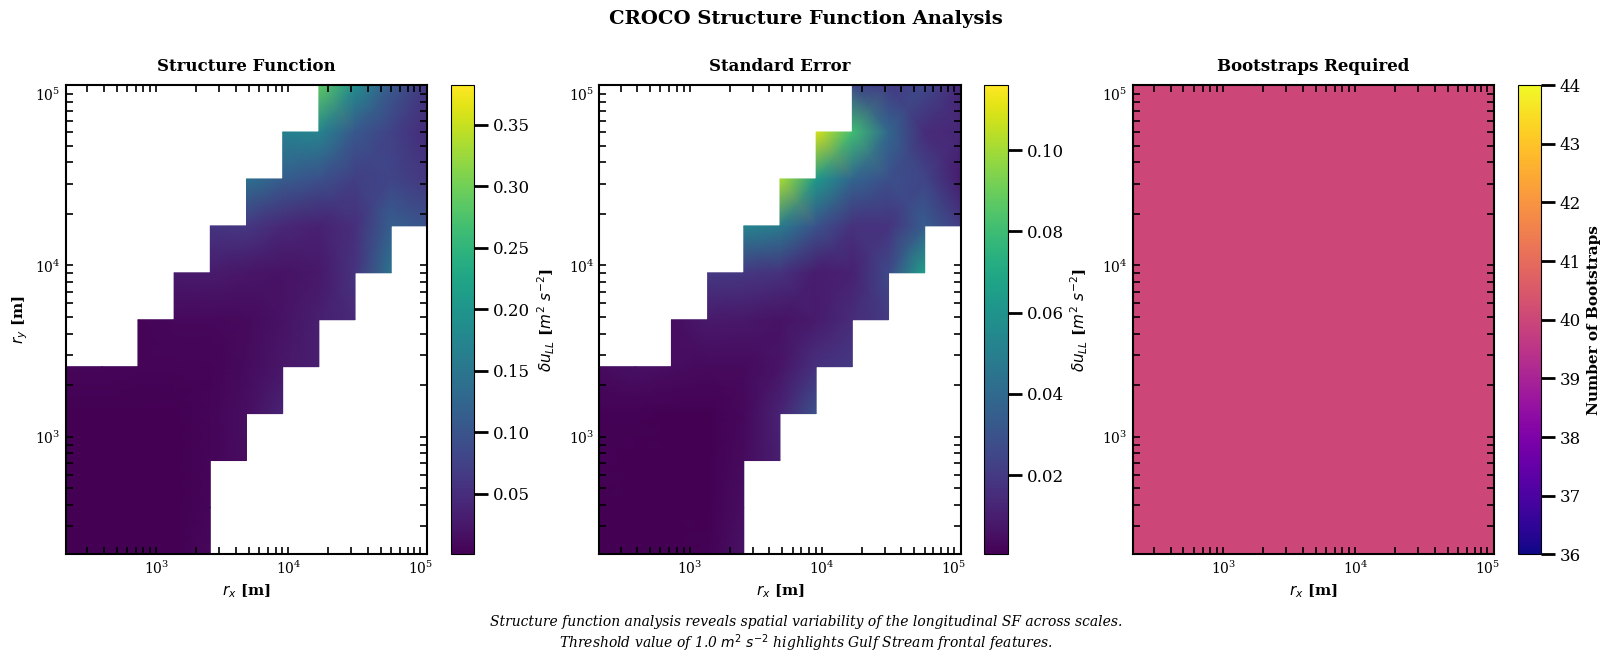

In [14]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Common settings for all plots
plot_titles = ['Structure Function', 'Standard Error', 'Bootstraps Required']
cmaps = ['viridis', 'viridis', 'plasma']
labels = [r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', 'Number of Bootstraps']

# Data to plot
data_to_plot = [sf_result.sf.sel(time=0.5/f,method='nearest'), sf_result.sf_std.sel(time=0.5/f,method='nearest'), sf_result.nbootstraps.sel(time=1/f,method='nearest')]

for i, (ax, data, title, cmap, label) in enumerate(zip(axes, data_to_plot, plot_titles, cmaps, labels)):
    # Create the plot with specific shading for the first plot
    if i == 0:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    else:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    
    # Add colorbar with proper formatting
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=11, fontweight='bold')
    
    # Set axis labels and title
    ax.set_xlabel(r'$r_x$ [m]', fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$r_y$ [m]', fontsize=11, fontweight='bold')
    
    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add title
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Customize spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Customize tick parameters
    ax.tick_params(which='both', direction='in', width=1.2, length=5, 
                  labelsize=10, top=True, right=True)
    

    
    # Add scientific notation for axes
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Add main title for the entire figure
fig.suptitle('CROCO Structure Function Analysis', fontsize=14, fontweight='bold', y=1.08)

# Add annotation explaining the analysis
fig.text(0.5, -0.08, 
         'Structure function analysis reveals spatial variability of the longitudinal SF across scales.\n'
         'Threshold value of 1.0 $m^{2}~s^{-2}$ highlights Gulf Stream frontal features.',
         ha='center', fontsize=10, fontstyle='italic')

plt.show()

# Plot 2D SFs,$\delta_t = 1/8f$

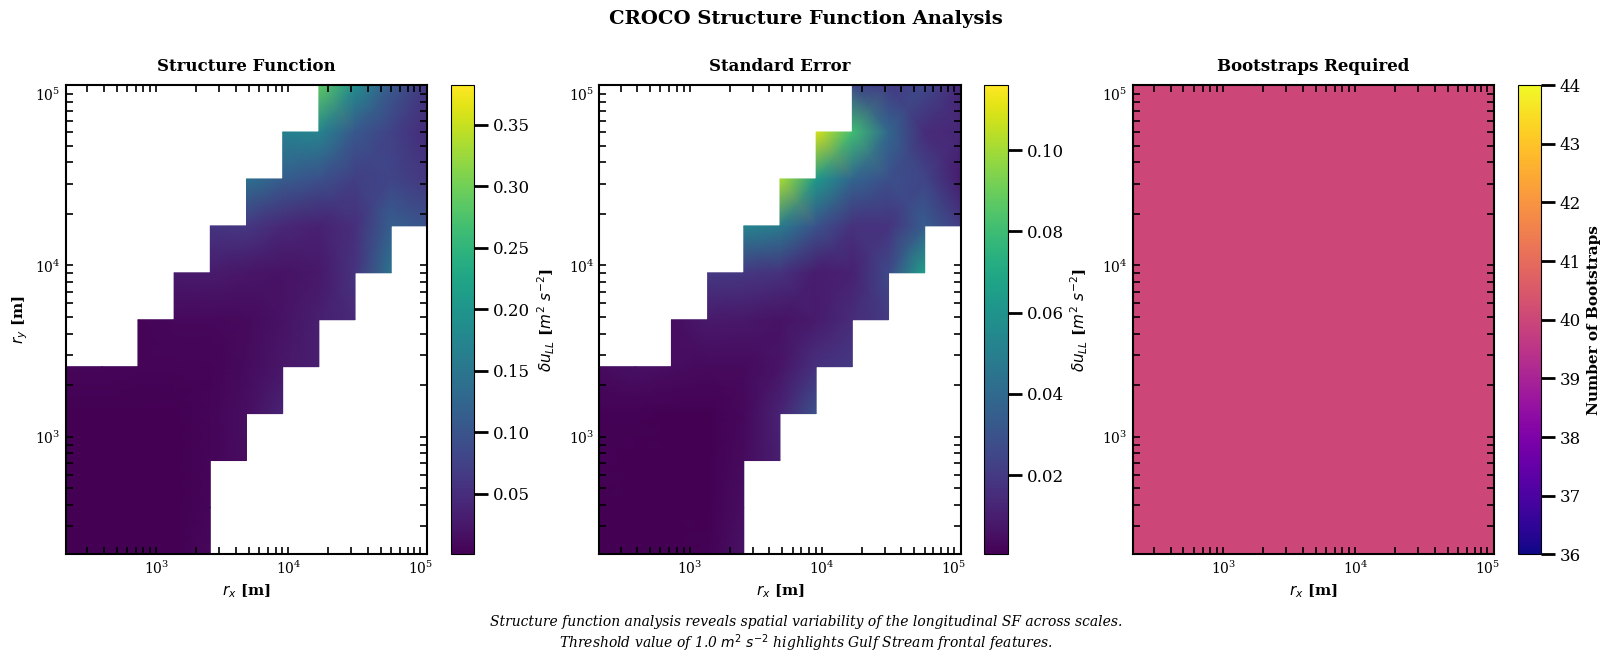

In [15]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Common settings for all plots
plot_titles = ['Structure Function', 'Standard Error', 'Bootstraps Required']
cmaps = ['viridis', 'viridis', 'plasma']
labels = [r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', 'Number of Bootstraps']

# Data to plot
data_to_plot = [sf_result.sf.sel(time=0.1/f,method='nearest'), sf_result.sf_std.sel(time=0.1/f,method='nearest'), sf_result.nbootstraps.sel(time=1/f,method='nearest')]

for i, (ax, data, title, cmap, label) in enumerate(zip(axes, data_to_plot, plot_titles, cmaps, labels)):
    # Create the plot with specific shading for the first plot
    if i == 0:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    else:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    
    # Add colorbar with proper formatting
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=11, fontweight='bold')
    
    # Set axis labels and title
    ax.set_xlabel(r'$r_x$ [m]', fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$r_y$ [m]', fontsize=11, fontweight='bold')
    
    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add title
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Customize spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Customize tick parameters
    ax.tick_params(which='both', direction='in', width=1.2, length=5, 
                  labelsize=10, top=True, right=True)
    

    
    # Add scientific notation for axes
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Add main title for the entire figure
fig.suptitle('CROCO Structure Function Analysis', fontsize=14, fontweight='bold', y=1.08)

# Add annotation explaining the analysis
fig.text(0.5, -0.08, 
         'Structure function analysis reveals spatial variability of the longitudinal SF across scales.\n'
         'Threshold value of 1.0 $m^{2}~s^{-2}$ highlights Gulf Stream frontal features.',
         ha='center', fontsize=10, fontstyle='italic')

plt.show()

# Isotropize Radial Bin SF

In [13]:
%%time  
def get_radially_binned_sf(ds_binned, r_bins=None):
    """
    Convert binned structure function results to a radially binned form.
    If a time dimension is present, returns sf(deltat, r) where r is the radial distance in the spatial plane.
    
    Parameters
    -----------
    ds_binned : xarray.Dataset
        Dataset with binned structure function from bin_sf_3d
    r_bins : array-like, optional
        Radial bins for spatial dimensions. If None, will create automatic bins.
        
    Returns
    --------
    xarray.Dataset
        Dataset with radially binned structure function results
    """
    # Check if we have time dimensions in the binned dataset
    time_dimensions = ds_binned.attrs.get('time_dimensions', '')
    time_dim = None
    
    if time_dimensions:
        time_dim = time_dimensions.split(',')[0]  # Use the first time dimension
        print(f"Found time dimension: {time_dim}")
    
    # Get the binned structure function and its dimensions
    dims = list(ds_binned.sf.dims)  # Should be ['z', 'y', 'x'] or similar
    
    # For space-time case
    if time_dim:
        print(f"Processing space-time data with time dimension: {time_dim}")
        
        # Identify the time dimension index
        time_dim_idx = dims.index(time_dim)
        
        # Get the spatial dimensions (the other two dimensions)
        spatial_dims = [dim for i, dim in enumerate(dims) if i != time_dim_idx]
        print(f"Spatial dimensions: {spatial_dims}")
        
        # Get the coordinates
        coords = {dim: ds_binned[dim].values for dim in dims}
        
        # Get the time bins from the original dataset
        time_coords = coords[time_dim]
        n_time_bins = len(time_coords)
        
        # For each spatial coordinate, calculate distance from origin
        # This is slightly different depending on which dimension is time
        if time_dim_idx == 0:  # z is time
            # Create a grid of the y, x coordinates
            Y, X = np.meshgrid(coords[spatial_dims[0]], coords[spatial_dims[1]], indexing='ij')
            # Calculate radial distance in the y-x plane
            R = np.sqrt(X**2 + Y**2)
        elif time_dim_idx == 1:  # y is time
            # Create a grid of the z, x coordinates
            Z, X = np.meshgrid(coords[spatial_dims[0]], coords[spatial_dims[1]], indexing='ij')
            # Calculate radial distance in the z-x plane
            R = np.sqrt(Z**2 + X**2)
        else:  # x is time
            # Create a grid of the z, y coordinates
            Z, Y = np.meshgrid(coords[spatial_dims[0]], coords[spatial_dims[1]], indexing='ij')
            # Calculate radial distance in the z-y plane
            R = np.sqrt(Z**2 + Y**2)
        
        # Create spatial distance bins if not provided
        if r_bins is None:
            r_min = np.min(R[R > 0]) / 2  # Avoid zero
            r_max = np.max(R) * 1.05      # Add a little margin
            # Use logarithmic bins for wide range
            if r_max / r_min > 10:
                r_bins = np.logspace(np.log10(r_min), np.log10(r_max), 20)
            else:
                r_bins = np.linspace(r_min, r_max, 20)
        
        # Calculate bin centers
        if r_bins[1] / r_bins[0] > 1.01:  # Log bins
            r_centers = np.sqrt(r_bins[:-1] * r_bins[1:])
            bin_type = 'logarithmic'
        else:  # Linear bins
            r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
            bin_type = 'linear'
        
        n_r_bins = len(r_centers)
        print(f"Using {n_r_bins} radial bins ({bin_type})")
        
        # Initialize arrays for results
        sf_rt_means = np.full((n_time_bins, n_r_bins), np.nan)
        sf_rt_stds = np.full((n_time_bins, n_r_bins), np.nan)
        count_rt = np.zeros((n_time_bins, n_r_bins), dtype=np.int32)
        
        # Get the binned structure function values
        sf_values = ds_binned.sf.values
        sf_std_values = ds_binned.sf_std.values
        count_values = ds_binned.point_counts.values
        
        # Loop through time bins
        for t_idx in range(n_time_bins):
            # Extract slice for this time bin
            if time_dim_idx == 0:  # z is time
                sf_slice = sf_values[t_idx, :, :]
                sf_std_slice = sf_std_values[t_idx, :, :]
                count_slice = count_values[t_idx, :, :]
            elif time_dim_idx == 1:  # y is time
                sf_slice = sf_values[:, t_idx, :]
                sf_std_slice = sf_std_values[:, t_idx, :]
                count_slice = count_values[:, t_idx, :]
            else:  # x is time
                sf_slice = sf_values[:, :, t_idx]
                sf_std_slice = sf_std_values[:, :, t_idx]
                count_slice = count_values[:, :, t_idx]
            
            # Flatten for binning
            r_flat = R.flatten()
            sf_flat = sf_slice.flatten()
            sf_std_flat = sf_std_slice.flatten()
            count_flat = count_slice.flatten()
            
            # Remove NaN values
            valid_mask = ~np.isnan(sf_flat)
            r_flat = r_flat[valid_mask]
            sf_flat = sf_flat[valid_mask]
            sf_std_flat = sf_std_flat[valid_mask]
            count_flat = count_flat[valid_mask]
            
            if len(r_flat) == 0:
                continue
            
            # Bin by radial distance
            r_indices = np.clip(np.digitize(r_flat, r_bins) - 1, 0, n_r_bins - 1)
            
            # Calculate weighted means for each radial bin
            for r_idx in range(n_r_bins):
                bin_mask = r_indices == r_idx
                if not np.any(bin_mask):
                    continue
                    
                bin_sf = sf_flat[bin_mask]
                bin_counts = count_flat[bin_mask]
                
                # Use count-weighted average
                if np.sum(bin_counts) > 0:
                    sf_rt_means[t_idx, r_idx] = np.sum(bin_sf * bin_counts) / np.sum(bin_counts)
                    
                    # Calculate weighted standard deviation
                    if np.sum(bin_mask) > 1:
                        # Weighted variance calculation
                        weights = bin_counts / np.sum(bin_counts)
                        sf_rt_stds[t_idx, r_idx] = np.sqrt(np.sum(weights * (bin_sf - sf_rt_means[t_idx, r_idx])**2))
                    
                    count_rt[t_idx, r_idx] = np.sum(bin_counts)
        
        # Create output dataset for space-time case
        ds_radial = xr.Dataset(
            data_vars={
                'sf': ((time_dim, 'r'), sf_rt_means),
                'sf_std': ((time_dim, 'r'), sf_rt_stds),
                'point_counts': ((time_dim, 'r'), count_rt),
            },
            coords={
                'r': r_centers,
                time_dim: time_coords,
            },
            attrs={
                'order': ds_binned.attrs.get('order', ''),
                'function_type': ds_binned.attrs.get('function_type', ''),
                'variables': ds_binned.attrs.get('variables', ''),
                'bin_type_r': bin_type,
                'time_dimension': time_dim,
                'processing': 'radially_binned_in_spatial_plane'
            }
        )
        
        # Add bin edges to the dataset
        ds_radial['r_bins'] = (('r_edge'), r_bins)
        
        return ds_radial
    
    # For fully spatial case (true isotropization)
    else:
        print("Processing fully spatial data (3D isotropization)")
        
        # Get the coordinates
        x_coords = ds_binned[dims[2]].values
        y_coords = ds_binned[dims[1]].values
        z_coords = ds_binned[dims[0]].values
        
        # Create coordinate grids
        X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')
        
        # Calculate radial distance from origin
        R = np.sqrt(X**2 + Y**2 + Z**2)
        
        # Create radial bins if not provided
        if r_bins is None:
            r_min = np.min(R[R > 0]) / 2  # Avoid zero
            r_max = np.max(R) * 1.05      # Add a little margin
            if r_max / r_min > 10:
                r_bins = np.logspace(np.log10(r_min), np.log10(r_max), 20)
            else:
                r_bins = np.linspace(r_min, r_max, 20)
        
        # Calculate bin centers
        if r_bins[1] / r_bins[0] > 1.01:  # Log bins
            r_centers = np.sqrt(r_bins[:-1] * r_bins[1:])
            bin_type = 'logarithmic'
        else:  # Linear bins
            r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
            bin_type = 'linear'
        
        n_r_bins = len(r_centers)
        print(f"Using {n_r_bins} radial bins ({bin_type})")
        
        # Flatten all arrays for binning
        r_flat = R.flatten()
        sf_flat = ds_binned.sf.values.flatten()
        sf_std_flat = ds_binned.sf_std.values.flatten()
        count_flat = ds_binned.point_counts.values.flatten()
        
        # Remove NaN values
        valid_mask = ~np.isnan(sf_flat)
        r_flat = r_flat[valid_mask]
        sf_flat = sf_flat[valid_mask]
        sf_std_flat = sf_std_flat[valid_mask]
        count_flat = count_flat[valid_mask]
        
        if len(r_flat) == 0:
            raise ValueError("No valid data points found for binning")
        
        # Bin the data by radial distance
        r_indices = np.clip(np.digitize(r_flat, r_bins) - 1, 0, n_r_bins - 1)
        
        # Initialize arrays for binned results
        sf_means = np.full(n_r_bins, np.nan)
        sf_stds = np.full(n_r_bins, np.nan)
        count_totals = np.zeros(n_r_bins, dtype=np.int32)
        
        # Calculate weighted means for each radial bin
        for r_idx in range(n_r_bins):
            bin_mask = r_indices == r_idx
            if not np.any(bin_mask):
                continue
                
            bin_sf = sf_flat[bin_mask]
            bin_counts = count_flat[bin_mask]
            
            # Use count-weighted average
            if np.sum(bin_counts) > 0:
                sf_means[r_idx] = np.sum(bin_sf * bin_counts) / np.sum(bin_counts)
                
                # Calculate weighted standard deviation
                if np.sum(bin_mask) > 1:
                    # Weighted variance calculation
                    weights = bin_counts / np.sum(bin_counts)
                    sf_stds[r_idx] = np.sqrt(np.sum(weights * (bin_sf - sf_means[r_idx])**2))
                
                count_totals[r_idx] = np.sum(bin_counts)
        
        # Create output dataset for fully spatial case
        ds_iso = xr.Dataset(
            data_vars={
                'sf': (('r'), sf_means),
                'sf_std': (('r'), sf_stds),
                'point_counts': (('r'), count_totals),
            },
            coords={
                'r': r_centers,
            },
            attrs={
                'order': ds_binned.attrs.get('order', ''),
                'function_type': ds_binned.attrs.get('function_type', ''),
                'variables': ds_binned.attrs.get('variables', ''),
                'bin_type': bin_type,
                'processing': 'isotropic_3d'
            }
        )
        
        # Add bin edges to the dataset
        ds_iso['r_bins'] = (('r_edge'), r_bins)
        
        return ds_iso
        
bin_r = np.logspace(np.log10(150.), np.log10(155.0e3), 20)

iso_sf = get_radially_binned_sf(sf_result, r_bins=bin_r)


Found time dimension: time
Processing space-time data with time dimension: time
Spatial dimensions: ['y', 'x']
Using 19 radial bins (logarithmic)
CPU times: user 5.56 ms, sys: 4 μs, total: 5.57 ms
Wall time: 5.34 ms


# Plot Isotropic Longitudinal SF ($\delta r$, $\delta t$)

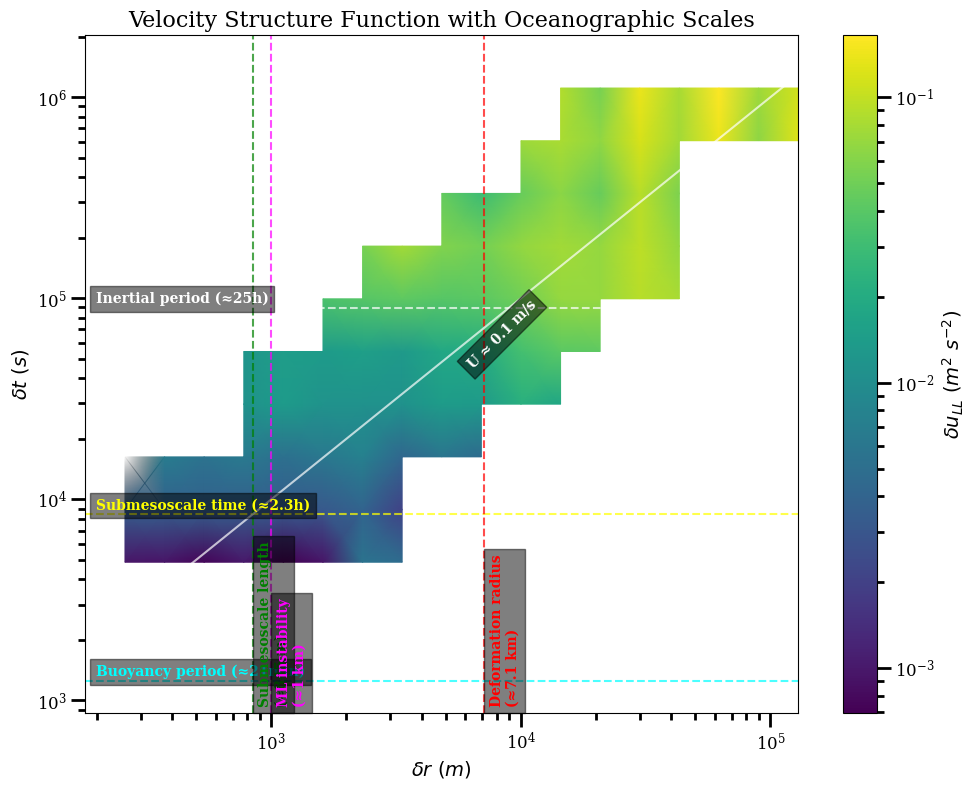

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Create the base plot
plt.figure(figsize=(10, 8))
pcm = plt.pcolormesh(iso_sf.r, iso_sf.time, iso_sf.sf, norm=LogNorm(), shading='gouraud')
plt.xscale('log')
plt.yscale('log')

# Characteristic scales based on f = 7e-5 and N = 5e-3
# Time scales
inertial_period = 2*np.pi/(7e-5)  # ≈ 25 hours ≈ 90,000 seconds
buoyancy_period = 2*np.pi/(5e-3)  # ≈ 21 minutes ≈ 1,257 seconds
submeso_time = 8450  # ≈ 2.3 hours, calculated from L/U

# Length scales
deformation_radius = 7143  # ≈ 7.1 km, calculated as NH/f
submeso_length = 845  # ≈ 845 m, calculated as R_d·(f/N)^(1/2)
mixed_layer_instability = 1000  # ≈ 1 km, typical scale for ML instabilities

# Add horizontal lines for time scales
plt.axhline(y=inertial_period, color='white', linestyle='--', alpha=0.7)
plt.text(plt.xlim()[0]*1.1, inertial_period*1.05, 'Inertial period (≈25h)', 
         color='white', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

plt.axhline(y=buoyancy_period, color='cyan', linestyle='--', alpha=0.7)
plt.text(plt.xlim()[0]*1.1, buoyancy_period*1.05, 'Buoyancy period (≈21min)', 
         color='cyan', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

plt.axhline(y=submeso_time, color='yellow', linestyle='--', alpha=0.7)
plt.text(plt.xlim()[0]*1.1, submeso_time*1.05, 'Submesoscale time (≈2.3h)', 
         color='yellow', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

# Add vertical lines for length scales
plt.axvline(x=deformation_radius, color='red', linestyle='--', alpha=0.7)
plt.text(deformation_radius*1.05, plt.ylim()[0]*1.1, 'Deformation radius\n(≈7.1 km)', 
         color='red', fontweight='bold', rotation=90, bbox=dict(facecolor='black', alpha=0.5))

plt.axvline(x=submeso_length, color='green', linestyle='--', alpha=0.7)
plt.text(submeso_length*1.05, plt.ylim()[0]*1.1, 'Submesoscale length\n(≈845 m)', 
         color='green', fontweight='bold', rotation=90, bbox=dict(facecolor='black', alpha=0.5))

plt.axvline(x=mixed_layer_instability, color='magenta', linestyle='--', alpha=0.7)
plt.text(mixed_layer_instability*1.05, plt.ylim()[0]*1.1, 'ML instability\n(≈1 km)', 
         color='magenta', fontweight='bold', rotation=90, bbox=dict(facecolor='black', alpha=0.5))

# Add a diagonal line representing a characteristic advection speed of 0.1 m/s
r_vals = np.logspace(np.log10(plt.xlim()[0]), np.log10(plt.xlim()[1]), 100)
t_vals = r_vals / 0.1  # δr/U
valid_indices = (t_vals >= plt.ylim()[0]) & (t_vals <= plt.ylim()[1])
if np.any(valid_indices):
    plt.loglog(r_vals[valid_indices], t_vals[valid_indices], 'w-', alpha=0.7)
    midpoint_idx = len(r_vals[valid_indices]) // 2
    mid_r = r_vals[valid_indices][midpoint_idx]
    mid_t = t_vals[valid_indices][midpoint_idx]
    plt.text(mid_r*1.2, mid_t*0.9, 'U ≈ 0.1 m/s', color='white', 
             fontweight='bold', rotation=45, bbox=dict(facecolor='black', alpha=0.5))

# Finalize the plot
plt.xlabel(r'$\delta r~(m)$', fontsize=14)
plt.ylabel(r'$\delta t~(s)$', fontsize=14)
plt.title('Velocity Structure Function with Oceanographic Scales', fontsize=16)
cbar = plt.colorbar(pcm, label=r'$\delta^{2} u ~(m^{2}~s^{-2})$')
cbar.ax.set_ylabel(r'$\delta u_{LL} ~(m^{2}~s^{-2})$', fontsize=14)



plt.tight_layout()
plt.show()

# Time Uncertainty

posx and posy should be finite values
posx and posy should be finite values


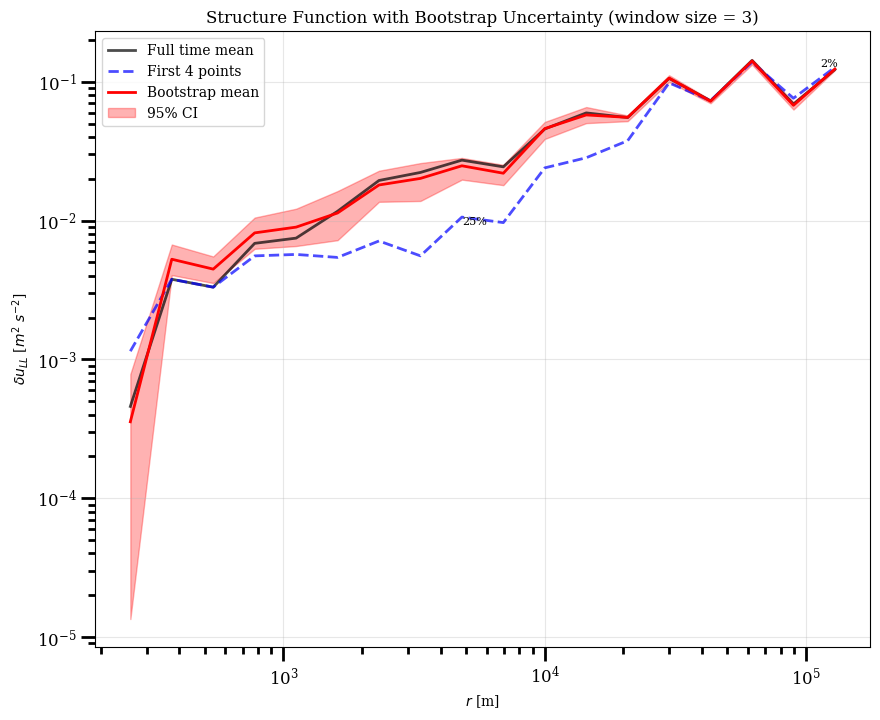

Relative uncertainties:
------------------------------
y = 2.06e+02: nan%
y = 7.26e+02: 19.7%
y = 4.82e+03: 25.3%
y = 3.20e+04: 25.6%
y = 1.13e+05: 1.6%


In [23]:
# Simple bootstrap approach for immediate use
import numpy as np
import matplotlib.pyplot as plt

# Quick bootstrap with sliding windows
window_size = 3
n_bootstrap = 5 # less than the number of possible windows
n_time = 11  # your time dimension size

# Create all possible windows
windows = []
for i in range(n_time - window_size + 1):
    windows.append(slice(i, i + window_size))
# Bootstrap by resampling windows
bootstrap_means = []
for _ in range(n_bootstrap):
    # Randomly sample windows with replacement
    sampled_windows = np.random.choice(len(windows), size=len(windows), replace=True)
    
    # Combine data from sampled windows
    combined_data = []
    for idx in sampled_windows:
        combined_data.append(iso_sf.sf.isel(time=windows[idx]))
    
    # Calculate mean across all sampled windows
    bootstrap_mean = xr.concat(combined_data, dim='time').mean('time')
    bootstrap_means.append(bootstrap_mean)

# Convert to array for easier calculation
bootstrap_array = np.array([b.values for b in bootstrap_means])

# Calculate statistics
mean_sf = np.mean(bootstrap_array, axis=0)
std_sf = np.std(bootstrap_array, axis=0)
ci_lower = np.percentile(bootstrap_array, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_array, 97.5, axis=0)

# Plot with uncertainty bands
plt.figure(figsize=(10, 8))

# Original full mean
plt.loglog(iso_sf.r, iso_sf.sf.mean('time'), 'k-', 
           linewidth=2, label='Full time mean', alpha=0.7)

# First window mean (as in your example)
plt.loglog(iso_sf.r, iso_sf.sf.isel(time=slice(0,4)).mean('time'), 
           'b--', linewidth=2, label='First 4 points', alpha=0.7)

# Bootstrap mean with confidence interval
plt.loglog(iso_sf.r, mean_sf, 'r-', linewidth=2, label='Bootstrap mean')
plt.fill_between(iso_sf.r.values, ci_lower, ci_upper, 
                 alpha=0.3, color='red', label='95% CI')

# Add relative uncertainty as text at a few points
y_vals = sf_result.y.values
for i in [0, len(y_vals)//2, -1]:
    rel_uncertainty = (std_sf[i] / mean_sf[i]) * 100
    plt.text(y_vals[i], mean_sf[i], f'{rel_uncertainty:.0f}%', 
             fontsize=8, ha='left', va='bottom')

plt.xlabel(r'$r$ [m]')
plt.ylabel(r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]')
plt.title(f'Structure Function with Bootstrap Uncertainty (window size = {window_size})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print uncertainty at different scales
print("Relative uncertainties:")
print("-" * 30)
for i in [0, len(y_vals)//4, len(y_vals)//2, 3*len(y_vals)//4, -1]:
    rel_unc = (std_sf[i] / mean_sf[i]) * 100
    print(f"y = {y_vals[i]:.2e}: {rel_unc:.1f}%")